Задание 2.1

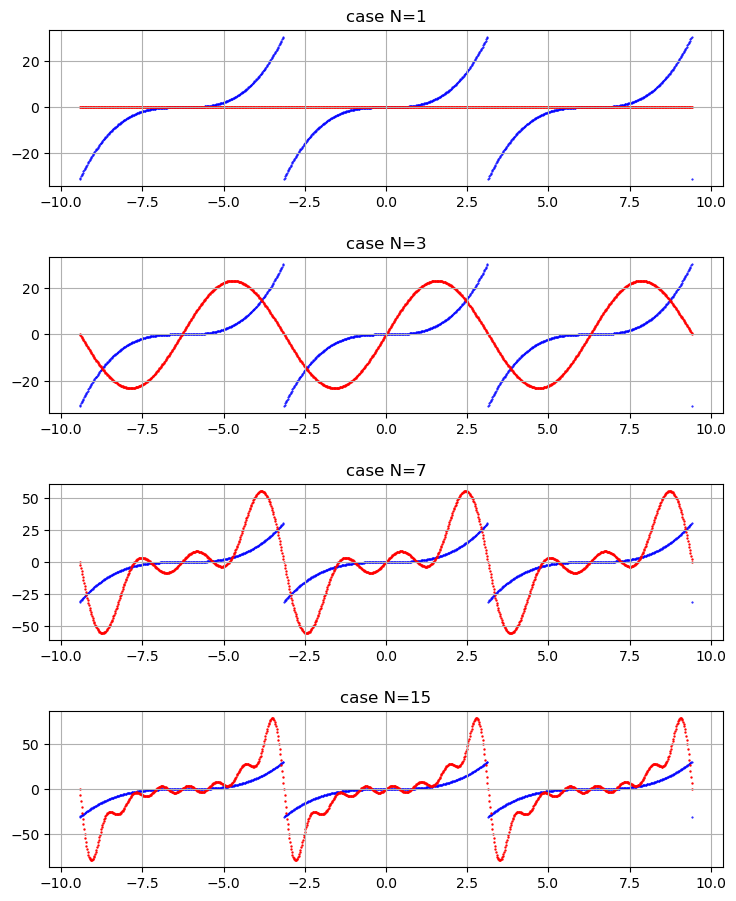

In [15]:
import numpy as np
import scipy.integrate as spi
import matplotlib.pyplot as plt


f = lambda x: (((x + T/2.) % T) - T/2.) ** 3

# Исходные данные
T = 2 * np.pi      # Период
x1 = -3 * np.pi    # Нижняя граница области определения функции
x2 = 3 * np.pi     # Верхняя граница области определения функции
Nx = 1000   # Дискретизация по оси X

# Ось X
x_range = np.linspace(x1, x2, Nx)

# Эталонные кривые исходной функции f(x)
y_true = f(x_range)

# Расчет интеграла от комплексной функции
def integral_complex(func, a, b, **kwargs):
    def real_func(x):
        return np.real(func(x))
    def imag_func(x):
        return np.imag(func(x))
    real_integral = spi.quad(real_func, a, b, **kwargs)
    imag_integral = spi.quad(imag_func, a, b, **kwargs)
    integral = (real_integral[0] + 1j*imag_integral[0], real_integral[1:], imag_integral[1:])
    return integral

# Вычисление коэффициентов ряда Фурье c[-N/2],.., c[0], .., c[N/2-1] (всего N)
def fourier_coeffs(func, N, a, b):
    result = []
    N1 = -int(N/2)
    N2 = int((N-1)/2)
    for k in range(N1, N2+1):
        ck = (1./T) * integral_complex(lambda x: func(x) * np.exp(-1j * 2 * np.pi * k * x / T), a, b)[0]
        result.append(ck)
    return np.array(result)

# Аппроксимация (восстановление) функции f(x) при помощи коэффициентов c[k]
def fourier_fit(x, c):
    result = 0. + 0.j
    N = len(c)
    N1 = -int(N/2)
    N2 = int((N-1)/2)
    for k in range(N1, N2+1):
        result += c[k+int(N/2)] * np.exp(1j * 2. * np.pi * k * x / T)
    return result

# Вычисление коэффициентов, аппроксимация, построение графиков при разных N
N_all = [1, 3, 7, 15]

fig, axs = plt.subplots(len(N_all), 1, figsize=(8, 10))
fig.tight_layout(rect=[0, 0, 1, 0.95], pad=3.0)
row = 0
for N in N_all:
    C = fourier_coeffs(f, N, x1, x2)
    y_approx = fourier_fit(x_range, C)
    y_approx_real = [y.real for y in y_approx]
    axs[row].set_title('case N=' + str(N))
    axs[row].grid(True)
    axs[row].scatter(x_range, y_true, color='blue', s=1, marker='.')
    axs[row].scatter(x_range, y_approx_real, color='red', s=2, marker='.')
    row += 1
plt.show()


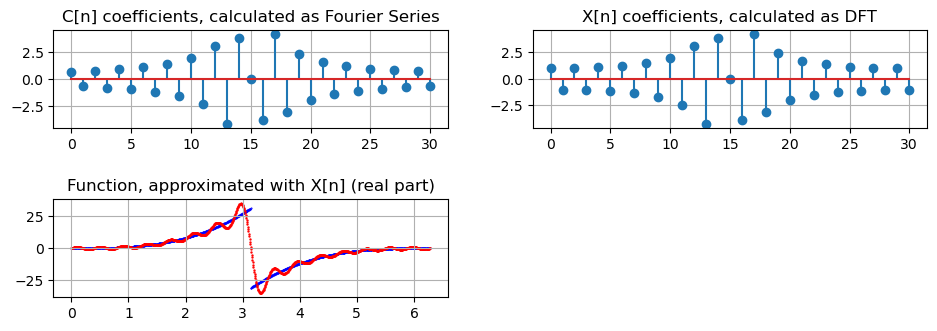

In [16]:
from scipy import fftpack

x1 = 0    # Нижняя граница области определения функции
x2 = 2*np.pi     # Верхняя граница области определения функции

# Ось X
x_range = np.linspace(x1, x2, Nx)

# Эталонные кривые исходной функции f(x)
y_true = f(x_range)

# Количество коэффициентов
N_dft = 31

# Расчет коэффициентов ряда Фурье
cn = fourier_coeffs(f, N_dft, x1, x2)

# Определение функции f(x) на одном периоде
x_period = np.arange(0, T, T/N_dft)
fx = f(x_period)

# Расчет коэффициентов методом ДПФ
X = fftpack.fft(fx) / N_dft
X = np.roll(X, int(N_dft/2))

# Аппроксимация функции f(x) новым набором коэффициентов
y_approx = fourier_fit(x_range, X)
y_approx_real = [y.real for y in y_approx]

# Отображение результатов
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(10, 4))
fig.tight_layout(rect=[0, 0, 1, 0.95], pad=3.0)
axes[0,0].stem(np.imag(cn))
axes[0,0].grid(True)
axes[0,0].set_title('C[n] coefficients, calculated as Fourier Series')
axes[0,1].stem(np.imag(X))
axes[0,1].grid(True)
axes[0,1].set_title('X[n] coefficients, calculated as DFT')
axes[1,0].scatter(x_range, y_true, color='blue', s=1, marker='.')
axes[1,0].scatter(x_range, y_approx_real, color='red', s=2, marker='.')
axes[1,0].set_title('Function, approximated with X[n] (real part)')
axes[1,0].grid(True)
axes[1,1].set_visible(False) 
plt.show()

Задание 2.2

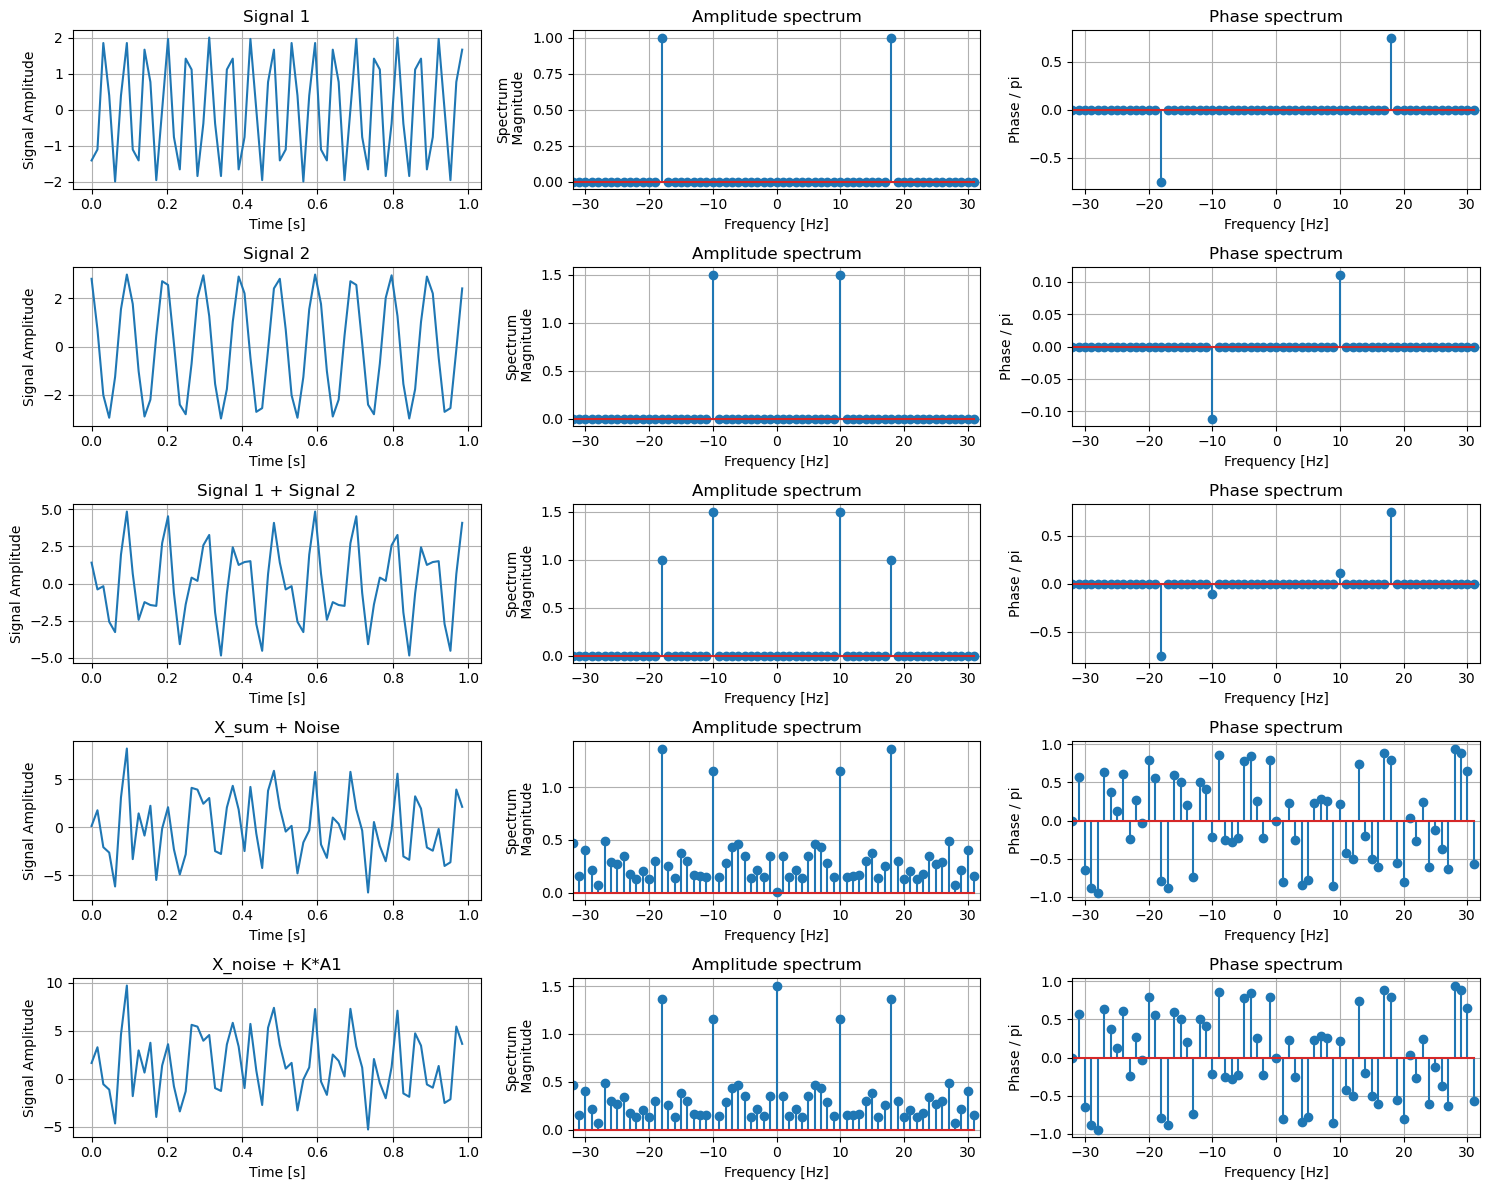

In [17]:
Amp1 = 18 % 4                # Амплитуда 1 сигнала
Amp2 = (18 + 1) % 4          # Амплитуда 2 сигнала
f01  = 18                    # Частота 1 гармонического сигнала в Гц
f02  = 10                    # Частота 2 гармонического сигнала в Гц
phi01 = 3*np.pi/4            # Начальная фаза 1 гармонического сигнала
phi02 = 2*np.pi/18           # Начальная фаза 2 гармонического сигнала
fs = 64                      # Частота дискретизации в Гц
tau = 1                      # Длительность сигналов
N = 64                       # Размер ДПФ (количество гармоник)
A_noise = 2 + 18 % 4         # Амплитуда шума
K = 0.25 * (1 + 18 % 8)      # Константа

# Оси времени и частоты
t = np.linspace(0, tau, N, endpoint = False)
f = fftpack.fftfreq(N) * fs

# Генерация двух комплексных гармонических сигналов
x1 = Amp1 * np.cos(2 * np.pi * f01 * t + phi01)
x2 = Amp2 * np.cos(2 * np.pi * f02 * t + phi02)
xsum = x1 + x2
noise = np.random.default_rng().uniform(-A_noise, A_noise, N)
xnoise = xsum + noise
xka1 = xnoise + K * Amp1

# Дискретное преобразование Фурье
X1 = fftpack.fft(x1) / N
X2 = fftpack.fft(x2) / N
Xsum = fftpack.fft(xsum) / N
Xnoise = fftpack.fft(xnoise) / N
Xka1 = fftpack.fft(xka1) / N

# Амплитудный и фазовый частотный спектры 

A1 = np.abs(X1);
A2 = np.abs(X2);
Asum = np.abs(Xsum);
Anoise = np.abs(Xnoise);
Aka1 = np.abs(Xka1);

P1 = np.arctan2(np.imag(X1), (np.real(X1)+1e-6)); 
P2 = np.arctan2(np.imag(X2), (np.real(X2)+1e-6));
Psum = np.arctan2(np.imag(Xsum), (np.real(Xsum)+1e-6));
Pnoise = np.arctan2(np.imag(Xnoise), (np.real(Xnoise)+1e-6));
Pka1 = np.arctan2(np.imag(Xka1), (np.real(Xka1)+1e-6));

# ПРИМЕЧАНИЕ. Для того, чтобы избавиться от неопределенности типа 0/0 при вычислении фазового спектра, 
# прибавим к знаменателю достаточно малое число, чтобы частное было близко к нулю, и корректно отображалось на графике. 
# В противном случае, в точках с нулевыми гармониками мы будем видеть случайные значения, полученные в результате 
# деления малых чисел, близких к 0, с ограниченной точностью, что не очень адекватно отразит изучаемые свойства спектров. 

# Отображение группами (subplot)
fig, axes = plt.subplots(nrows=5, ncols=3, figsize=(15, 12))
for i in range(0,5):
    if i == 0:
        x = x1
        A = A1
        P = P1
        Title = 'Signal 1'
    elif i == 1:
        x = x2
        A = A2
        P = P2
        Title = 'Signal 2'
    elif i == 2:
        x = xsum
        A = Asum
        P = Psum
        Title = 'Signal 1 + Signal 2'
    elif i == 3:
        x = xnoise
        A = Anoise
        P = Pnoise
        Title = 'X_sum + Noise'
    else:
        x = xka1
        A = Aka1
        P = Pka1
        Title = 'X_noise + K*A1'
    axes[i,0].plot(t, x)
    axes[i,0].grid(True)
    axes[i,0].set_xlabel('Time [s]')
    axes[i,0].set_ylabel('Signal Amplitude')
    axes[i,0].title.set_text(Title)
    axes[i,1].stem(f, A)
    axes[i,1].grid(True)
    axes[i,1].set_xlabel('Frequency [Hz]')
    axes[i,1].set_ylabel('Spectrum\n Magnitude')
    axes[i,1].set_xlim(-fs/2, fs/2)
    axes[i,1].title.set_text('Amplitude spectrum')
    axes[i,2].stem(f, P / np.pi)
    axes[i,2].grid(True)
    axes[i,2].set_xlabel('Frequency [Hz]')
    axes[i,2].set_ylabel('Phase / pi')
    axes[i,2].set_xlim(-fs/2, fs/2)
    axes[i,2].title.set_text('Phase spectrum')
fig.tight_layout()
plt.show()


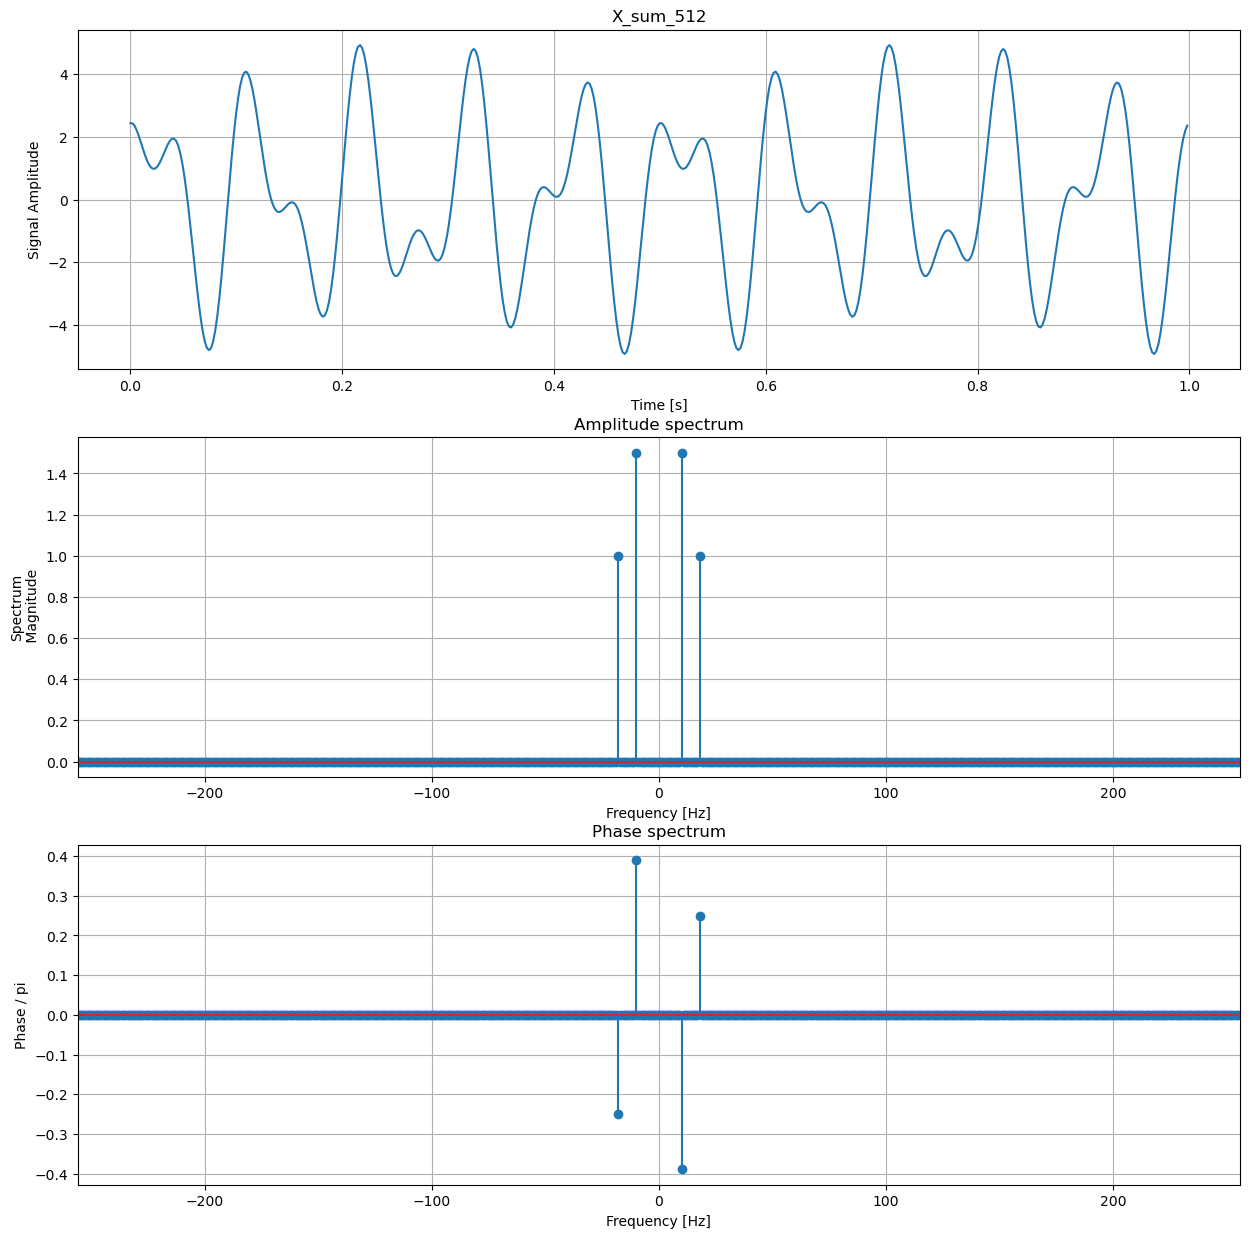

In [18]:
t512 = np.linspace(0, tau, 512, endpoint = False)
f512 = fftpack.fftfreq(512) * 512

x1_512 = Amp1 * np.sin(2 * np.pi * f01 * t512 + phi01)
x2_512 = Amp2 * np.sin(2 * np.pi * f02 * t512 + phi02)
xsum_512 = x1_512 + x2_512

Xsum_512 = fftpack.fft(xsum_512) / 512

Asum_512 = np.abs(Xsum_512);
Psum_512 = np.arctan2(np.imag(Xsum_512), (np.real(Xsum_512)+1e-6))

fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(15, 15))
axes[0].plot(t512, xsum_512)
axes[0].grid(True)
axes[0].set_xlabel('Time [s]')
axes[0].set_ylabel('Signal Amplitude')
axes[0].title.set_text('X_sum_512')
axes[1].stem(f512, Asum_512)
axes[1].grid(True)
axes[1].set_xlabel('Frequency [Hz]')
axes[1].set_ylabel('Spectrum\n Magnitude')
axes[1].set_xlim(-512/2, 512/2)
axes[1].title.set_text('Amplitude spectrum')
axes[2].stem(f512, Psum_512 / np.pi)
axes[2].grid(True)
axes[2].set_xlabel('Frequency [Hz]')
axes[2].set_ylabel('Phase / pi')
axes[2].set_xlim(-512/2, 512/2)
axes[2].title.set_text('Phase spectrum')

Задание 2.3

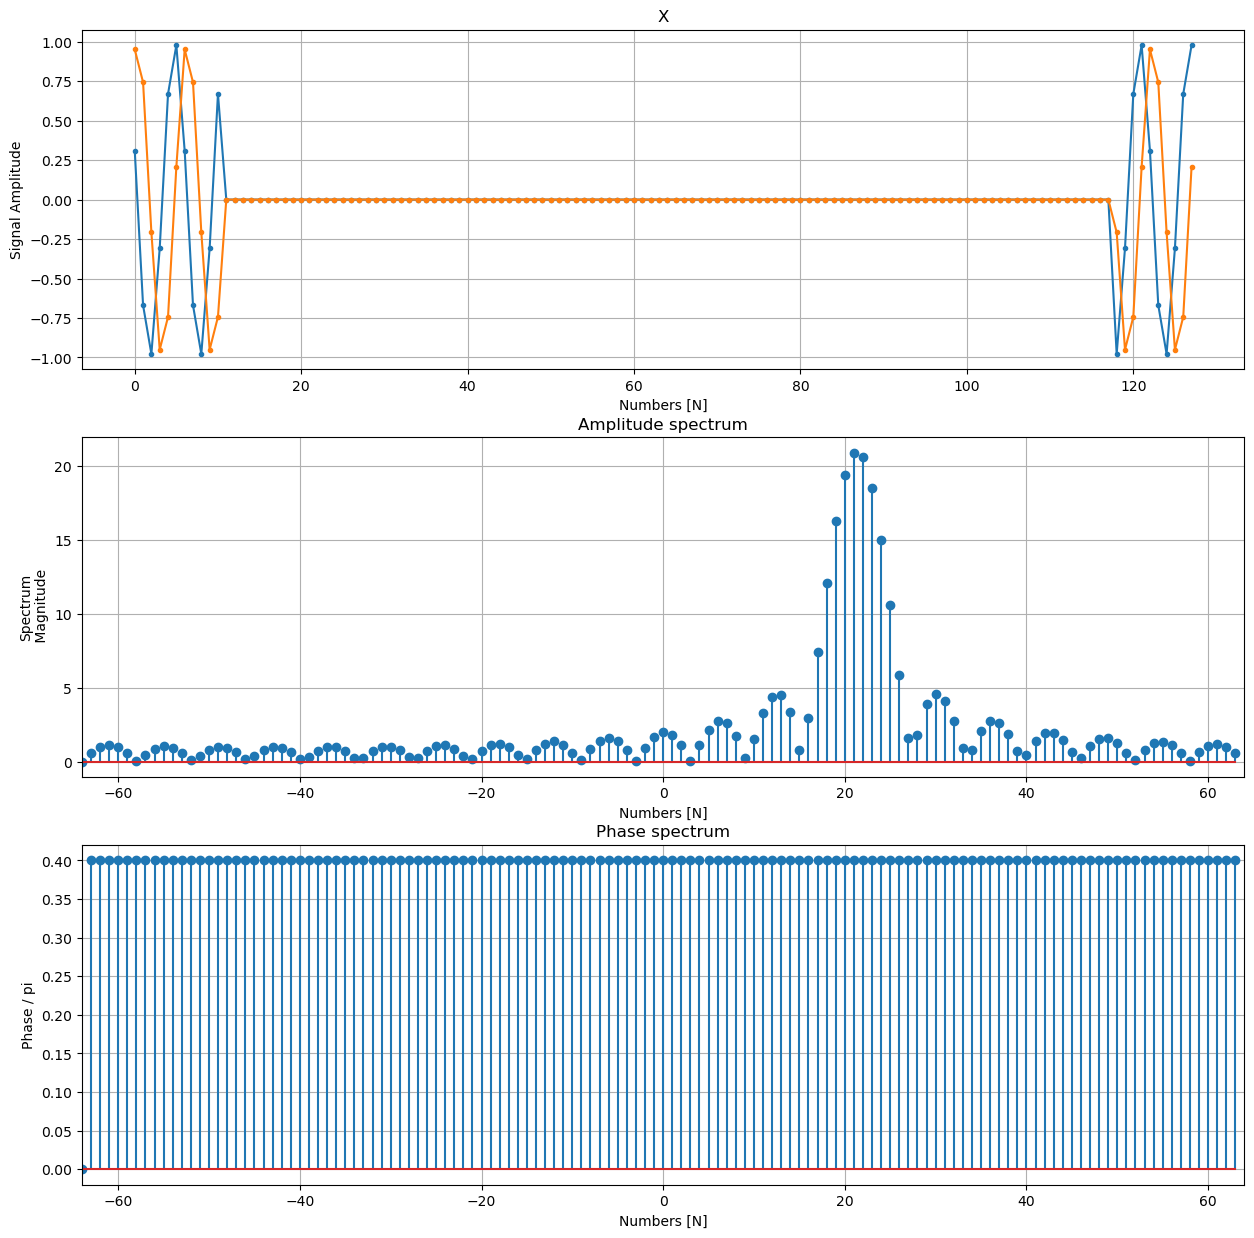

In [58]:
f0  = 1 + 18 % 4                  # Частота комплексного сигнала в Гц
phi0 = 2*np.pi / (3 + 18 % 4)     # Начальная фаза комплексного сигнала
N = 128                           # Размер ДПФ (количество гармоник)
Ni = 21                           # длина исходного сигнала в отсчетах
T = 1 / (3 * f0 * (18 % 8))       # период дискретизации
s = ((-1) ** (18 % 2)) * (18 % 8)

# Оси времени и частоты
t = np.concatenate((np.arange(0, N//2 + 1), np.arange(-N//2 + 1, 0))) * T
f = fftpack.fftfreq(N) * N
tochkas = np.concatenate((np.ones((Ni + 1)//2), np.zeros(N - Ni), np.ones((Ni - 1)//2)))

# Генерация комплексного гармонического сигнала
x = np.exp(1j * (2 * np.pi * f0 * t + phi0)) * tochkas

# Дискретное преобразование Фурье
X = fftpack.fft(x)

# Амплитудный и фазовый частотный спектры 
A = np.abs(X);
P = np.arctan(np.imag(X) / (np.real(X)+1e-6));
fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(15, 15))
axes[0].plot(np.real(x), '.-')
axes[0].plot(np.imag(x), '.-')
axes[0].grid(True)
axes[0].set_xlabel('Numbers [N]')
axes[0].set_ylabel('Signal Amplitude')
axes[0].title.set_text('X')
axes[1].stem(f, A)
axes[1].grid(True)
axes[1].set_xlabel('Numbers [N]')
axes[1].set_ylabel('Spectrum\n Magnitude')
axes[1].set_xlim(-N/2, N/2)
axes[1].title.set_text('Amplitude spectrum')
axes[2].stem(f, P / np.pi)
axes[2].grid(True)
axes[2].set_xlabel('Numbers [N]')
axes[2].set_ylabel('Phase / pi')
axes[2].set_xlim(-N/2, N/2)
axes[2].title.set_text('Phase spectrum')

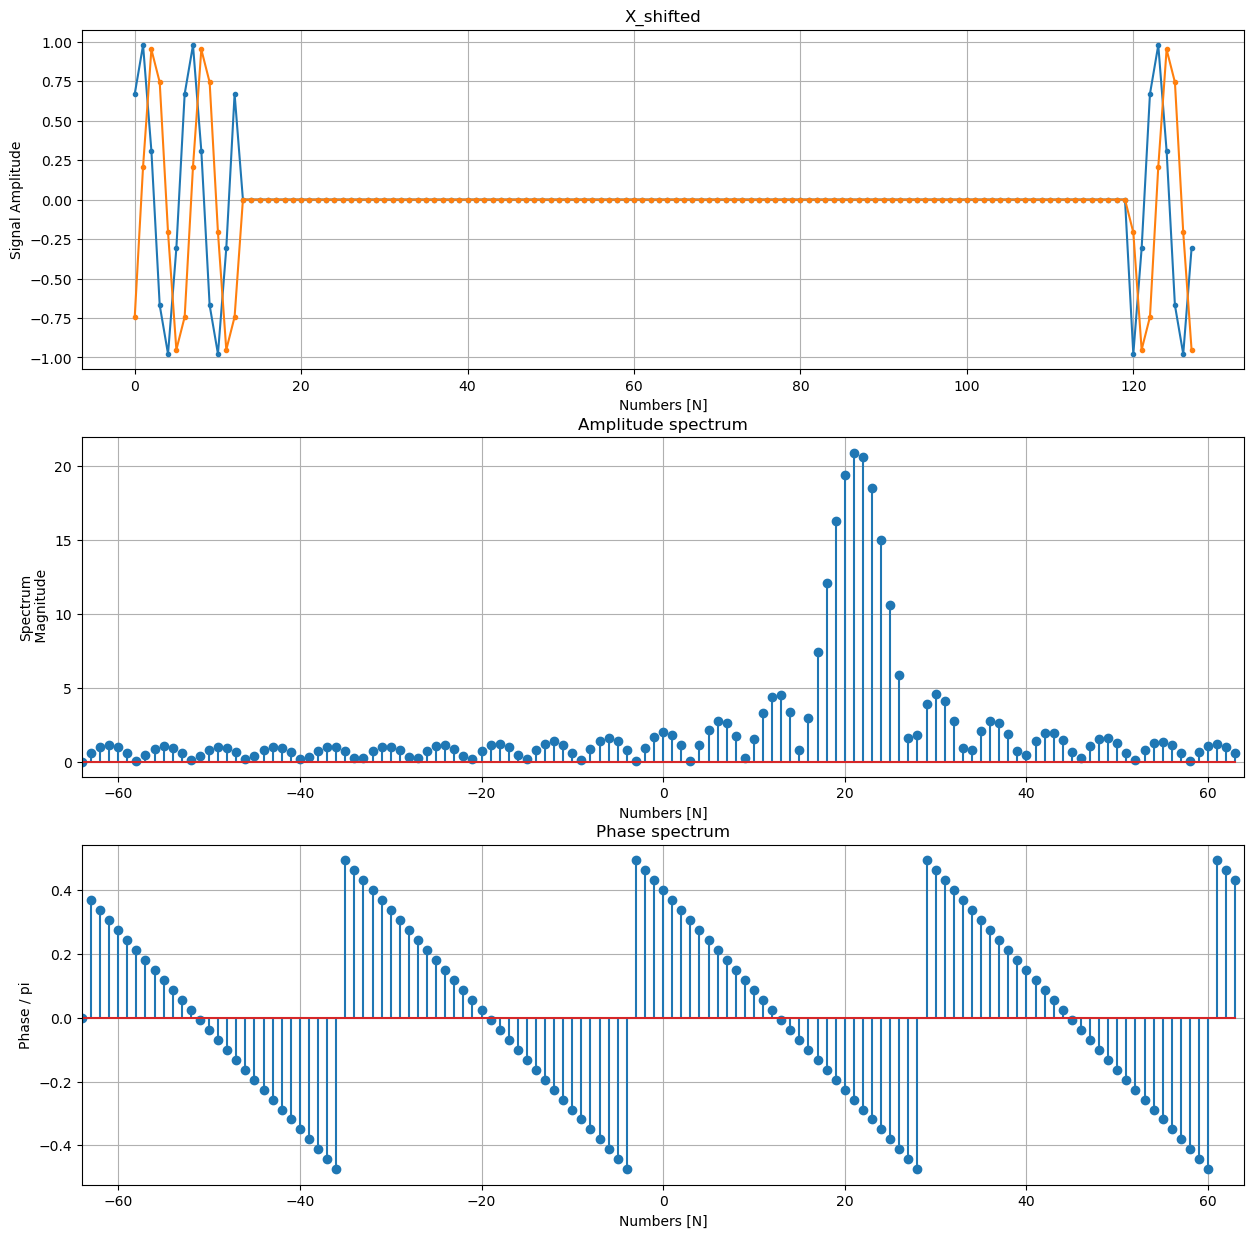

In [59]:
# Смещение на s
x_shift = np.roll(x, s)

# Дискретное преобразование Фурье
X = fftpack.fft(x_shift)

# Амплитудный и фазовый частотный спектры
A = np.abs(X);
P = np.arctan(np.imag(X) / (np.real(X)+1e-6));
fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(15, 15))
axes[0].plot(np.real(x_shift), '.-')
axes[0].plot(np.imag(x_shift), '.-')
axes[0].grid(True)
axes[0].set_xlabel('Numbers [N]')
axes[0].set_ylabel('Signal Amplitude')
axes[0].title.set_text('X_shifted')
axes[1].stem(f, A)
axes[1].grid(True)
axes[1].set_xlabel('Numbers [N]')
axes[1].set_ylabel('Spectrum\n Magnitude')
axes[1].set_xlim(-N/2, N/2)
axes[1].title.set_text('Amplitude spectrum')
axes[2].stem(f, P / np.pi)
axes[2].grid(True)
axes[2].set_xlabel('Numbers [N]')
axes[2].set_ylabel('Phase / pi')
axes[2].set_xlim(-N/2, N/2)
axes[2].title.set_text('Phase spectrum')

5. Рассчитать теоретические параметры спектров и сравить их с результатами, полученными при моделировании (на этапах 1-4):
- величину главного максимума амплитудного спектра: $A = N_{i} = 21$;
- положение главного максимума амплитудного спектра $f_{0}^{`}$ (в номерах отсчета спектра): $f_{0}^{`}=f_{0}TF_{s}=3*1/18*128=21.333$;
- нули амплитудного спектра: $f_{1}^{`}=\frac{1}{t_{i}}=\frac{1}{TN_{i}}=\frac{N}{N_{i}}\frac{F_{s}}{N}=\frac{128}{21}*\frac{F_{s}}{N}=6.095$ отсчетов

- характер наклона фазового спектра: $\phi(\mu)=\Delta\phi(\mu)+\phi_{0} = -s\mu\frac{2\pi}{N}+\phi_{0} = -2*6.095*2\pi/128 + 2\pi/5=0.658, 0.658/\pi=0.209$


Дополнительное задание 3

real part diff:  7.275957614183426e-12
imag part diff:  1.4551915228366852e-11


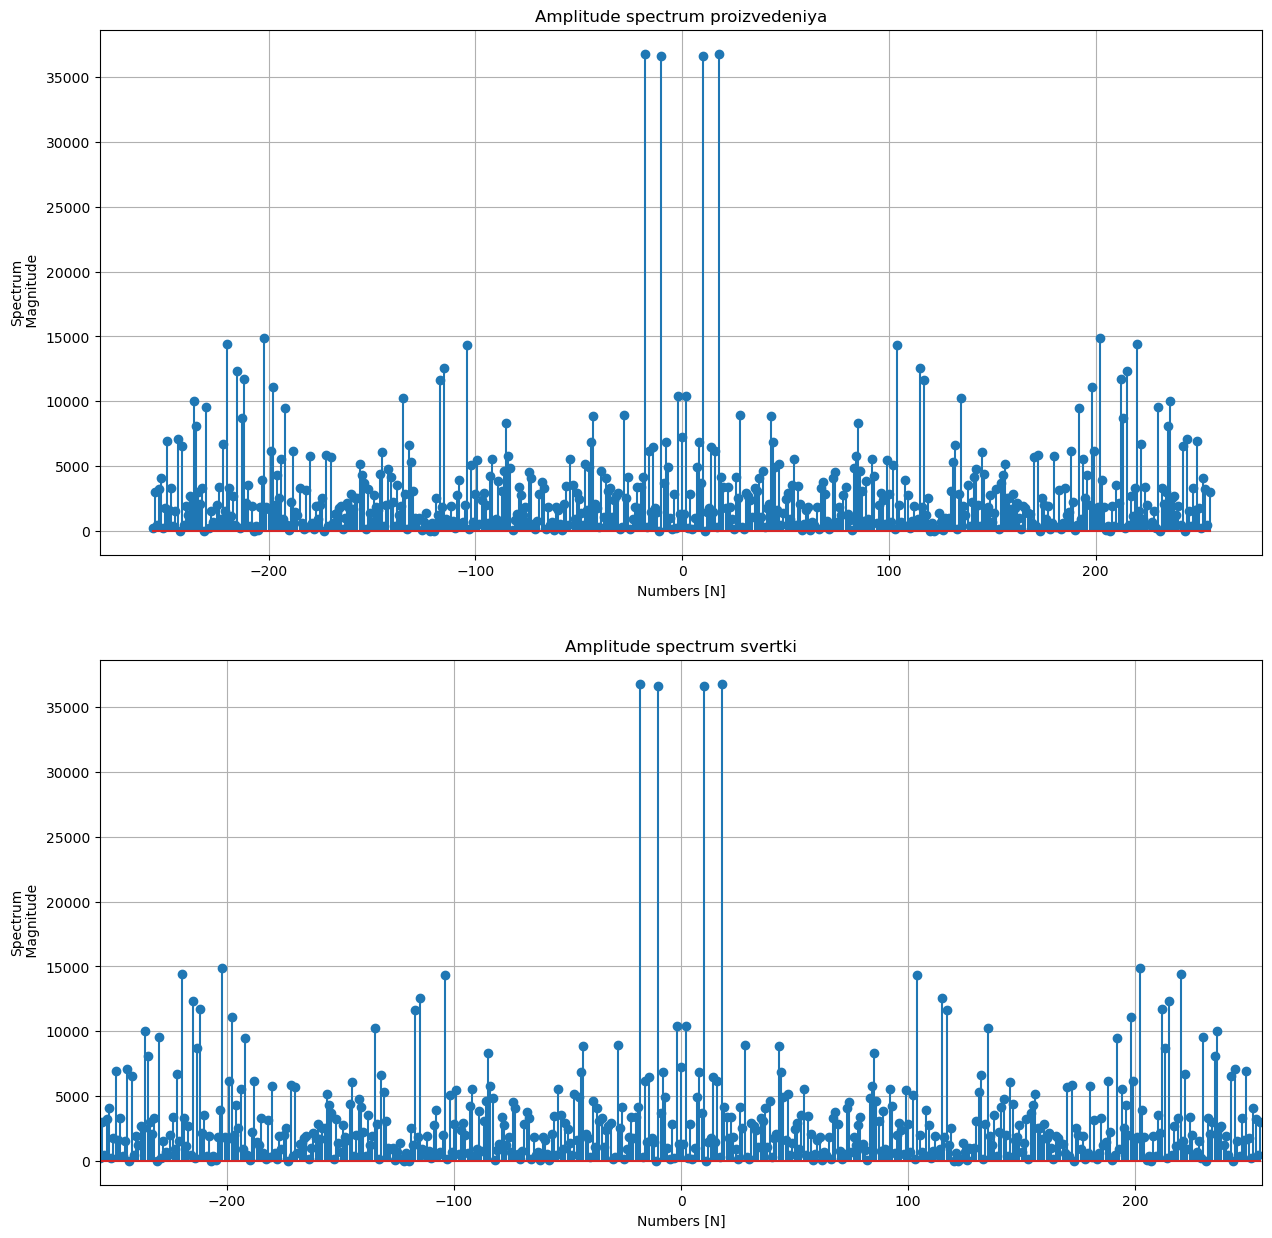

In [21]:
Amp1 = 18 % 4                # Амплитуда 1 сигнала
Amp2 = (18 + 1) % 4          # Амплитуда 2 сигнала
f01  = 18                    # Частота 1 гармонического сигнала в Гц
f02  = 10                    # Частота 2 гармонического сигнала в Гц
phi01 = 3*np.pi/4            # Начальная фаза 1 гармонического сигнала
phi02 = 2*np.pi/18           # Начальная фаза 2 гармонического сигнала
fs = 512                     # Частота дискретизации в Гц
tau = 1                      # Длительность сигналов
N = 512                      # Размер ДПФ (количество гармоник)
A_noise = 2 + 18 % 4         # Амплитуда шума

# Оси времени и частоты
t = np.linspace(0, tau, N, endpoint = False)
f = fftpack.fftfreq(N) * fs

# Генерация двух комплексных гармонических сигналов
noise = np.random.default_rng().uniform(-A_noise, A_noise, N)
x1 = Amp1 * np.sin(2 * np.pi * f01 * t + phi01) + noise
x2 = Amp2 * np.sin(2 * np.pi * f02 * t + phi02) + noise
svertka = np.real(np.fft.ifft(np.fft.fft(x1) * np.fft.fft(x2)))

# Дискретное преобразование Фурье
X1 = fftpack.fft(x1)
X2 = fftpack.fft(x2)
prod = X1 * X2
dpf_svertki = fftpack.fft(svertka)

print("real part diff: ", max(np.real(prod - dpf_svertki)))
print("imag part diff: ", max(np.imag(prod - dpf_svertki)))

# Амплитудно-частотный спектр 

Ap = np.abs(prod);
As = np.abs(dpf_svertki);

# ПРИМЕЧАНИЕ. Для того, чтобы избавиться от неопределенности типа 0/0 при вычислении фазового спектра, 
# прибавим к знаменателю достаточно малое число, чтобы частное было близко к нулю, и корректно отображалось на графике. 
# В противном случае, в точках с нулевыми гармониками мы будем видеть случайные значения, полученные в результате 
# деления малых чисел, близких к 0, с ограниченной точностью, что не очень адекватно отразит изучаемые свойства спектров. 

# Отображение группами (subplot)
fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(15, 15))
axes[0].stem(f, Ap)
axes[0].grid(True)
axes[0].set_xlabel('Numbers [N]')
axes[0].set_ylabel('Spectrum\n Magnitude')
axes[0].title.set_text('Amplitude spectrum proizvedeniya')
axes[1].stem(f, As)
axes[1].grid(True)
axes[1].set_xlabel('Numbers [N]')
axes[1].set_ylabel('Spectrum\n Magnitude')
axes[1].set_xlim(-N/2, N/2)
axes[1].title.set_text('Amplitude spectrum svertki')